### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

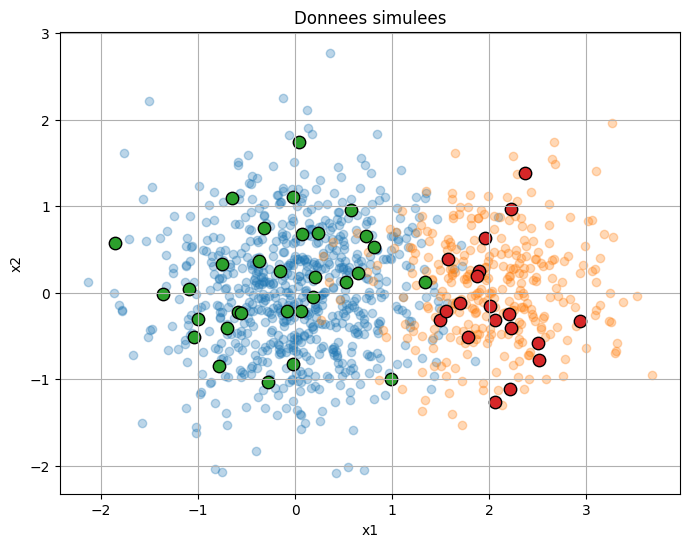

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def creer_donnees(n_points, decalage, proba_classe1):
    labels = (np.random.rand(n_points) < proba_classe1).astype(int)
    points = np.zeros((n_points, 2))
    
    centre0 = [0, 0]
    centre1 = [decalage, 0]
    
    cov0 = [[0.5, 0], [0, 0.5]]
    cov1 = [[0.4, 0], [0, 0.4]]
    
    for i in range(n_points):
        if labels[i] == 0:
            points[i] = np.random.multivariate_normal(centre0, cov0)
        else:
            points[i] = np.random.multivariate_normal(centre1, cov1)
    
    return points, labels


np.random.seed(42)
train_points, train_labels = creer_donnees(50, 2, 0.3)
test_points, test_labels = creer_donnees(1000, 2, 0.3)

plt.figure(figsize=(8, 6))

plt.scatter(test_points[test_labels == 0, 0], test_points[test_labels == 0, 1], alpha=0.3)
plt.scatter(test_points[test_labels == 1, 0], test_points[test_labels == 1, 1], alpha=0.3)

plt.scatter(train_points[train_labels == 0, 0], train_points[train_labels == 0, 1], s=80, edgecolor='black')
plt.scatter(train_points[train_labels == 1, 0], train_points[train_labels == 1, 1], s=80, edgecolor='black')

plt.title("Donnees simulees")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)

plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

$$
f(x) = 1 \iff \frac{P(Y=1 \mid X=x)}{P(Y=0 \mid X=x)} > 1
$$

$$
\frac{P(Y=1 \mid X=x)}{P(Y=0 \mid X=x)} = \frac{p \, f_1(x)}{(1-p)\, f_0(x)}
$$

$$
\text{Decision boundary: } \frac{p \, f_1(x)}{(1-p)\, f_0(x)} = 1
$$

$$
f_k(x) = \frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}} 
\exp\left(-\frac{1}{2}(x-\mu_k)^T \Sigma_k^{-1}(x-\mu_k)\right), \quad k \in \{0,1\}
$$

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

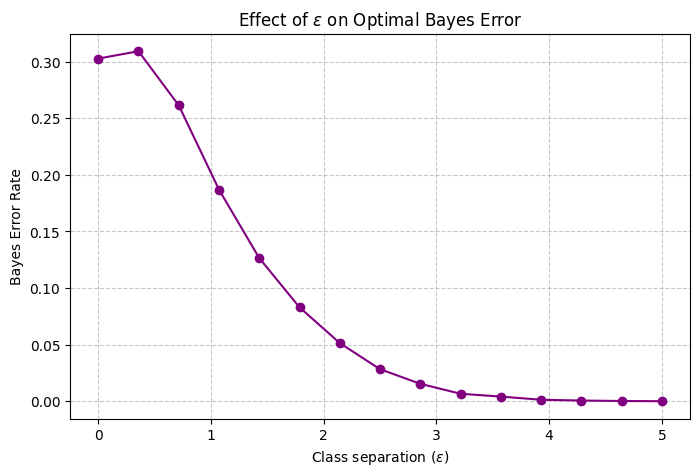

In [2]:
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels

class OptimalBayesClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, epsilon=2.0, p=0.30):
        self.epsilon = epsilon
        self.p = p

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = unique_labels(y)
        self.is_fitted_ = True
        return self

    def predict(self, X):
        check_is_fitted(self, 'is_fitted_')
        X = check_array(X)

        mu0, mu1 = [0, 0], [self.epsilon, 0]
        s0 = [[0.5, 0], [0, 0.5]]
        s1 = [[0.4, 0], [0, 0.4]]

        p0 = (1 - self.p) * multivariate_normal.pdf(X, mu0, s0)
        p1 = self.p * multivariate_normal.pdf(X, mu1, s1)

        return self.classes_[(p1 > p0).astype(int)]
    
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Test different values of epsilon
epsilons = np.linspace(0, 5, 15)
bayes_errors = []

for eps in epsilons:
    # Generate a large dataset to approximate the true error
    X_val, y_val = creer_donnees(10000, decalage=eps, proba_classe1=0.3)
    
    # Instantiate and predict using your custom classifier
    clf = OptimalBayesClassifier(epsilon=eps, p=0.3)
    clf.fit(X_val, y_val) 
    preds = clf.predict(X_val)
    
    # Calculate error
    error = 1 - accuracy_score(y_val, preds)
    bayes_errors.append(error)

# Plotting the curve
plt.figure(figsize=(8, 5))
plt.plot(epsilons, bayes_errors, marker='o', color='purple')
plt.xlabel("Class separation ($\\varepsilon$)")
plt.ylabel("Bayes Error Rate")
plt.title("Effect of $\\varepsilon$ on Optimal Bayes Error")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

QDA is best because the data is Gaussian and the two classes have different covariances.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [3]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# models
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
logreg = LogisticRegression()
X_train, y_train = train_points, train_labels
X_test, y_test = test_points, test_labels
# train
lda.fit(X_train, y_train)
qda.fit(X_train, y_train)
logreg.fit(X_train, y_train)

# predictions
y_pred_lda = lda.predict(X_test)
y_pred_qda = qda.predict(X_test)
y_pred_log = logreg.predict(X_test)

# errors
err_lda = 1 - accuracy_score(y_test, y_pred_lda)
err_qda = 1 - accuracy_score(y_test, y_pred_qda)
err_log = 1 - accuracy_score(y_test, y_pred_log)

err_lda, err_qda, err_log

(0.06599999999999995, 0.05400000000000005, 0.05500000000000005)

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [4]:

X_test_new, y_test_new = creer_donnees(1000, decalage=0.5, proba_classe1=0.7)

y_pred_lda_new = lda.predict(X_test_new)
y_pred_qda_new = qda.predict(X_test_new)
y_pred_log_new = logreg.predict(X_test_new)

err_lda_new = 1 - accuracy_score(y_test_new, y_pred_lda_new)
err_qda_new = 1 - accuracy_score(y_test_new, y_pred_qda_new)
err_log_new = 1 - accuracy_score(y_test_new, y_pred_log_new)

print(f"LDA Error on new distribution: {err_lda_new:.4f}")
print(f"QDA Error on new distribution: {err_qda_new:.4f}")
print(f"LogReg Error on new distribution: {err_log_new:.4f}")

LDA Error on new distribution: 0.5680
QDA Error on new distribution: 0.6380
LogReg Error on new distribution: 0.6200


Yes Theory: More data helps the model learn the true patterns better, making it more accurate.
Practice: As the training size grows, the QDA test error will drop and get as close as possible to the Bayes error limit.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

I removed useless columns (PassengerId, Ticket, Cabin), created a Title feature from names, handled missing values, and encoded categorical variables with one-hot encoding while scaling numerical ones.

(b)

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

I used a soft voting classifier combining Logistic Regression, SVM, Random Forest, Decision Tree, and KNN, with hyperparameters tuned using GridSearchCV. This ensemble was chosen because it combines linear and nonlinear models, making it more robust. The final Kaggle score was 0.77.